In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import os, sys

sys.path.insert(0, os.path.abspath(".."))

from src.constants import COLOR_EXP as COLOR_0, COLOR_REC as COLOR_1, SHADE_COL, SHADE_A, LW
from src.data_loader import load_macro_data, load_asset_data
from src.preprocess import prepare_macro_data, train_test_split
from src.hmm_model import HMMRegimeModel
from src.plots import (plot_regime_states, plot_regime_probs,
                        plot_series_colored, plot_series_shaded,
                        plot_frontiers, plot_backtest, plot_regime_nber, _fmt_matrix)
from src.portfolio import (estimate_regime_moments, optimize_regimes,
                            efficient_frontier, shrinkage_diagnostics)
from src.metrics import compute_metrics
from src.backtest import run_backtest, print_metrics_table

# Backward-compat wrappers
def fit_hmm(X, K=2, n_iter=200, n_restarts=10, tol=1e-6, random_state=42):
    return HMMRegimeModel(n_states=K, n_iter=n_iter, n_restarts=n_restarts,
                           tol=tol, random_state=random_state).fit(X)

def get_smoothed_probs(model, X): return model.smoothed_probs(X)
def get_filtered_probs(model, X): return model.filtered_probs(X)

plot_hmm_states      = lambda d, s, title="HMM Regime States": plot_regime_states(d, s, title)
plot_hmm_state_probs = lambda d, p, title="HMM State Probabilities": plot_regime_probs(d, p, title)

## Description

- Goal: implement MVO to determine optimal portfolio weights with state-conditional asset returns and covariance matrix
- Methodology:
  - Step 1: Use 13 macroeconomic indicators to classify states (K=2)
  - Step 2: Estimate state-conditional mean and covariance (Ledoit-Wolf shrinkage)
  - Step 3: Implement MVO for each state to determine optimal portfolio weights
  - Step 4: Compare with static portfolios and backtest on historical test data

This notebook implements Steps 1-4 for the **Gaussian HMM** using `hmmlearn`.

## Data preparation

Standardize macroeconomic indicators and prepare train/test arrays.

In [2]:
macro_df = load_macro_data("../data/macro_clean.csv")
macro_df.head()

,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply
Date,,,,,,,,,,,,,
1990-02-28,0.766531,0.212161,-0.176815,0.086523,0.648227,-0.517277,0.338459,-0.860618,-1.015353,0.112648,-0.816259,-0.973845,-0.117535
1990-03-31,0.370694,-0.144198,-0.176815,-0.056857,0.933078,-0.577370,0.033559,-1.001067,-1.092009,0.277788,0.453545,-1.387900,-0.208114
1990-04-30,-0.367467,0.581797,0.366229,0.272514,0.056672,-0.934117,0.005227,-1.113426,-1.015353,-0.052492,0.645214,-0.410427,-0.175312
1990-05-31,0.182830,-0.439503,0.004200,-0.054564,-0.234552,-0.572546,-0.284832,-0.818483,-0.993451,-0.382773,-0.768342,-0.371336,-0.905236
1990-06-30,0.216754,-0.099147,-0.357829,0.083436,1.493735,-0.255118,-0.537116,-0.706123,-0.894894,0.663116,-0.528756,-0.371754,-0.084565


In [3]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   cpi                     431 non-null    float64
 5   oil_price               431 non-null    float64
 6   vix                     431 non-null    float64
 7   credit_spread           431 non-null    float64
 8   yield_curve_slope       431 non-null    float64
 9   fed_funds_rate          431 non-null    float64
 10  consumer_sentiment      431 non-null    float64
 11  housing_starts          431 non-null    float64
 12  m2_money_supply         431 non-null    float64
dtypes: float64(13)
memory usage: 47.1 KB


In [4]:
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)

In [5]:
X_train.shape, X_test.shape if X_test is not None else None

((431, 13), None)

## Model fitting

In [6]:
model = fit_hmm(X_train, K=2, n_iter=200, n_restarts=10, tol=1e-6, random_state=42)

Best log-likelihood (per sample): -5691.9189


## Extracting results

In [7]:
smoothed_probs_train = get_smoothed_probs(model, X_train)
print("Smoothed probs shape:", smoothed_probs_train.shape)
print("Sum to 1:", np.allclose(smoothed_probs_train.sum(axis=0), 1.0))

Smoothed probs shape: (2, 431)
Sum to 1: True


In [8]:
filtered_probs_train = get_filtered_probs(model, X_train)
print("Filtered probs shape:", filtered_probs_train.shape)
print("Sum to 1:", np.allclose(filtered_probs_train.sum(axis=0), 1.0))

Filtered probs shape: (2, 431)
Sum to 1: True


In [9]:
states_sequence = model.predict(X_train)
print("State counts:", np.unique(states_sequence, return_counts=True))

State counts: (array([0, 1]), array([394,  37]))


In [10]:
states_sequence_series = pd.Series(states_sequence, index=dates_train, name="HMM State")
states_sequence_series.value_counts()

HMM State
0    394
1     37
Name: count, dtype: int64

### Transition matrix

In [11]:
pd.DataFrame(model.transmat_,
             columns=[f"State {i}" for i in range(model.n_components)],
             index=[f"State {i}" for i in range(model.n_components)])

,State 0,State 1
State 0,0.972742,0.027258
State 1,0.290492,0.709508


In [12]:
print(f"Average duration in each state (expected number of consecutive months):")
for i, persistent_prob in enumerate(model.transmat_.diagonal()):
    print(f"State {i}: {1 / (1 - persistent_prob):.2f} months")

Average duration in each state (expected number of consecutive months):
State 0: 36.69 months
State 1: 3.44 months


### Conditional means and covariance matrices

In [13]:
pd.DataFrame(model.means_,
             columns=macro_df.columns,
             index=["State 0 (Expansion)", "State 1 (Recession)"]).T

,State 0 (Expansion),State 1 (Recession)
industrial_production,0.048157,-0.514527
real_person_income,0.027426,-0.293027
unemployment_rate,-0.024822,0.265207
initial_jobless_claims,-0.011718,0.125198
cpi,0.039257,-0.419432
oil_price,0.020371,-0.217652
vix,-0.103440,1.105177
credit_spread,-0.108350,1.157643
yield_curve_slope,-0.049909,0.533237
fed_funds_rate,0.059855,-0.639510


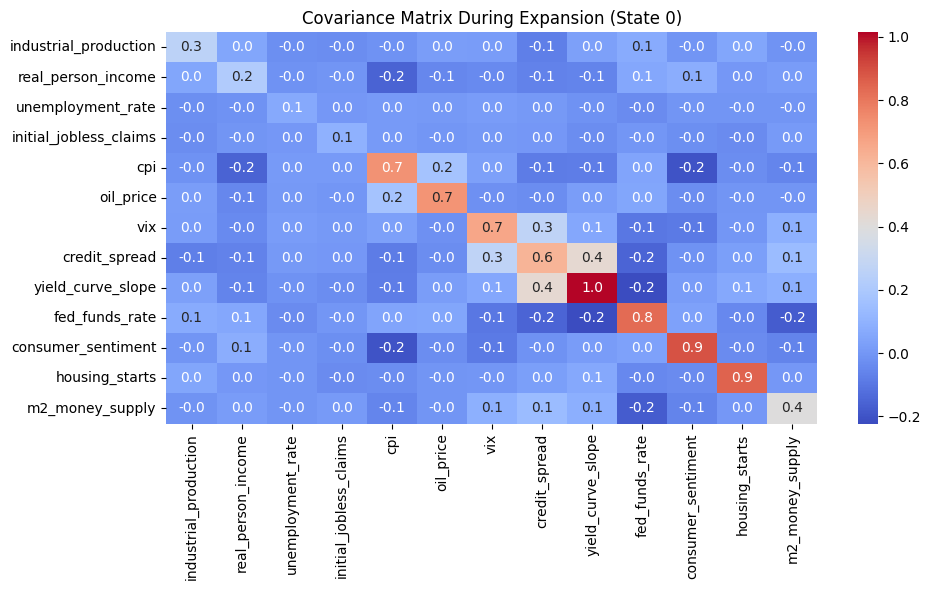

In [14]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(model.covars_[0], annot=True, fmt=".1f", cmap="coolwarm",
            xticklabels=macro_df.columns, yticklabels=macro_df.columns)
plt.title("Covariance Matrix During Expansion (State 0)")
plt.tight_layout()
plt.show()

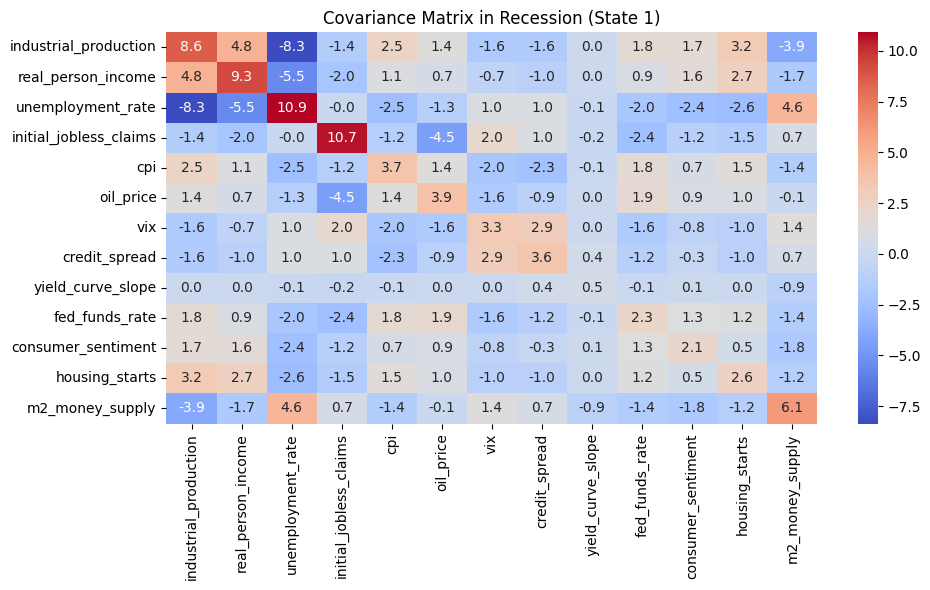

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(model.covars_[1], annot=True, fmt=".1f", cmap="coolwarm",
            xticklabels=macro_df.columns, yticklabels=macro_df.columns)
plt.title("Covariance Matrix in Recession (State 1)")
plt.tight_layout()
plt.show()

## Plotting results

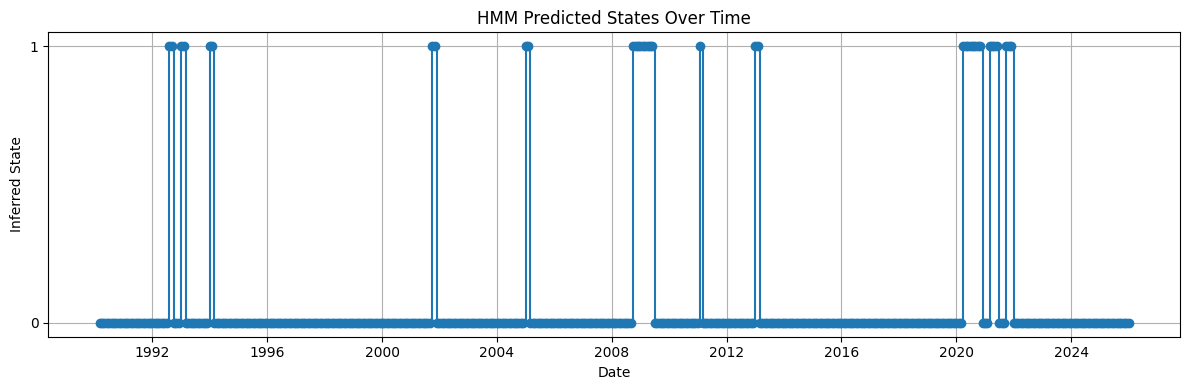

In [16]:
plot_hmm_states(dates_train, states_sequence, title="HMM Predicted States Over Time")
plt.show()

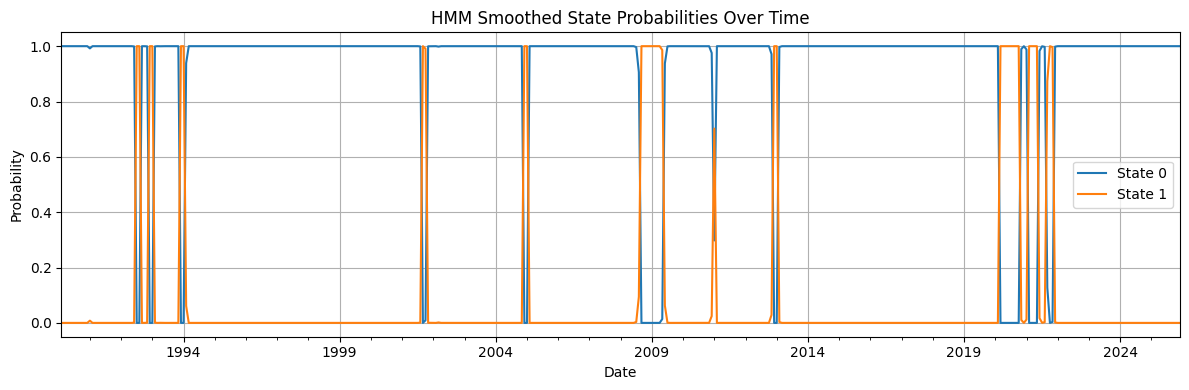

In [17]:
plot_hmm_state_probs(dates_train, smoothed_probs_train,
                     title="HMM Smoothed State Probabilities Over Time")
plt.show()

In [18]:
macro_df_expanded = macro_df.copy()
macro_df_expanded["HMM State"] = states_sequence

In [19]:
asset_df = load_asset_data("../data/market_clean.csv")
asset_df.columns = ['Equity', 'Bonds', 'Gold']
asset_df_expanded = asset_df.copy()
asset_df_expanded["HMM State"] = macro_df_expanded["HMM State"]

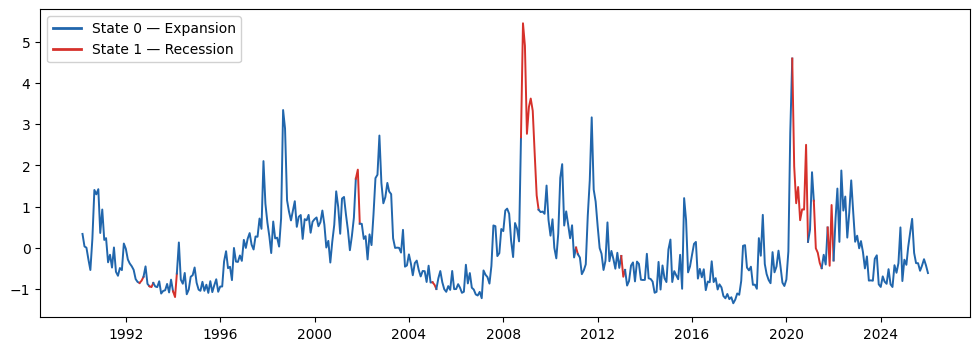

In [20]:
plot_series_colored(macro_df_expanded, series_name='vix', state_col='HMM State')
plt.show()

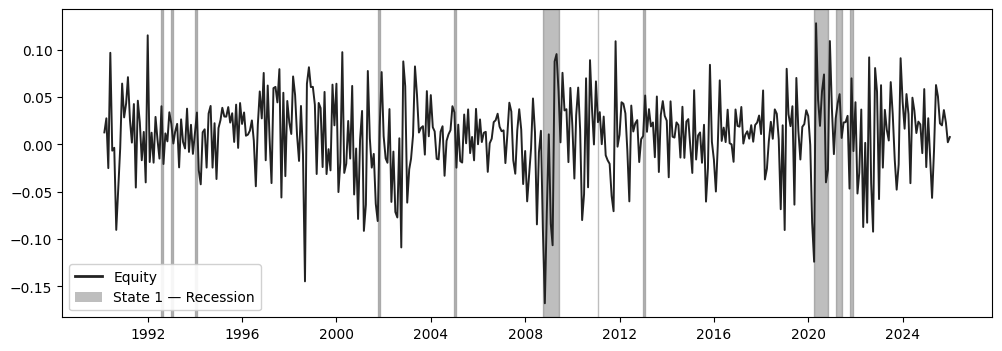

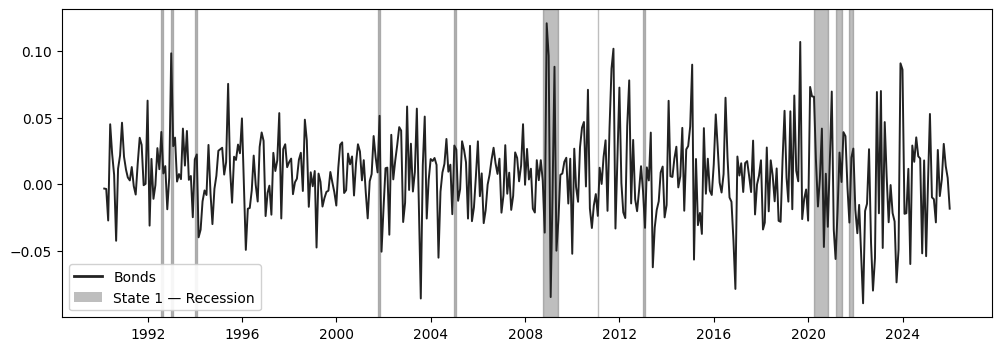

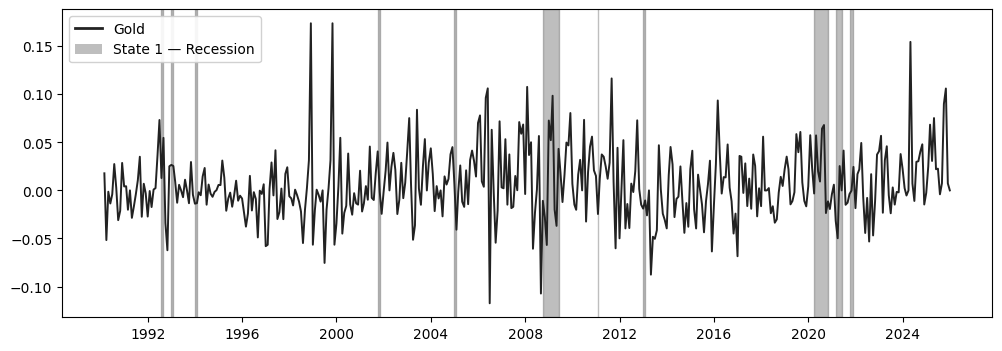

In [21]:
for col in asset_df.columns:
    plot_series_shaded(asset_df_expanded, series_name=col, state_col="HMM State", ax=None)
    plt.show()

## Portfolio optimization

Regime-conditional MVO using Ledoit-Wolf shrinkage estimated on the training set.

In [22]:
market_train, market_test = train_test_split(asset_df_expanded)
print("Last train date:", market_train.index[-1])
print("First test date:", market_test.index[0])

Last train date: 2018-09-30 00:00:00
First test date: 2018-10-31 00:00:00


In [23]:
moments = estimate_regime_moments(market_train,
                                  asset_cols=market_train.columns[:-1],
                                  state_col="HMM State")


── Regime 0  (322 observations) ──
  Mean returns (annualized %):
    Equity      : +12.09%
    Bonds       : +8.31%
    Gold        : +4.58%
  Ledoit-Wolf shrinkage α : 0.1796
  Implied annual volatilities:
    Equity      : 12.95%
    Bonds       : 9.71%
    Gold        : 12.48%

── Regime 1  (22 observations) ──
  Mean returns (annualized %):
    Equity      : -8.12%
    Bonds       : +20.11%
    Gold        : +8.54%
  Ledoit-Wolf shrinkage α : 0.9043
  Implied annual volatilities:
    Equity      : 18.77%
    Bonds       : 18.22%
    Gold        : 17.90%


In [24]:
shrinkage_diagnostics(moments, asset_cols=market_train.columns[:-1])


── Difference between shrunk and raw covariance ──

Regime 0  (α = 0.1796):
          Equity   Bonds    Gold
  Equity-0.00006 0.00003 0.00002
   Bonds 0.00003 0.00008-0.00003
    Gold 0.00002-0.00003-0.00003

Regime 1  (α = 0.9043):
          Equity   Bonds    Gold
  Equity-0.00157-0.00057 0.00044
   Bonds-0.00057 0.00010 0.00017
    Gold 0.00044 0.00017 0.00107


Regime-Conditional MVO

── min_variance  |  Regime 0 ──
  Expected return (ann.) : +8.54%
  Volatility     (ann.) : 6.42%
  Sharpe ratio          : 1.3289
  Weights:
    Equity      : 0.3044  (30.4%)
    Bonds       : 0.4486  (44.9%)
    Gold        : 0.2470  (24.7%)

── max_sharpe  |  Regime 0 ──
  Expected return (ann.) : +9.33%
  Volatility     (ann.) : 6.72%
  Sharpe ratio          : 1.3897
  Weights:
    Equity      : 0.4001  (40.0%)
    Bonds       : 0.4701  (47.0%)
    Gold        : 0.1298  (13.0%)

── max_return  |  Regime 0 ──
  Expected return (ann.) : +14.04%
  Volatility     (ann.) : 14.99%
  Sharpe ratio          : 0.9365
  Weights:
    Equity      : 0.9644  (96.4%)
    Bonds       : 0.5968  (59.7%)
    Gold        : -0.5612  (-56.1%)

── min_variance  |  Regime 1 ──
  Expected return (ann.) : +7.12%
  Volatility     (ann.) : 10.55%
  Sharpe ratio          : 0.6749
  Weights:
    Equity      : 0.3148  (31.5%)
    Bonds       : 0.3306  (33.1%)
    Gold        : 0.3546  (35.

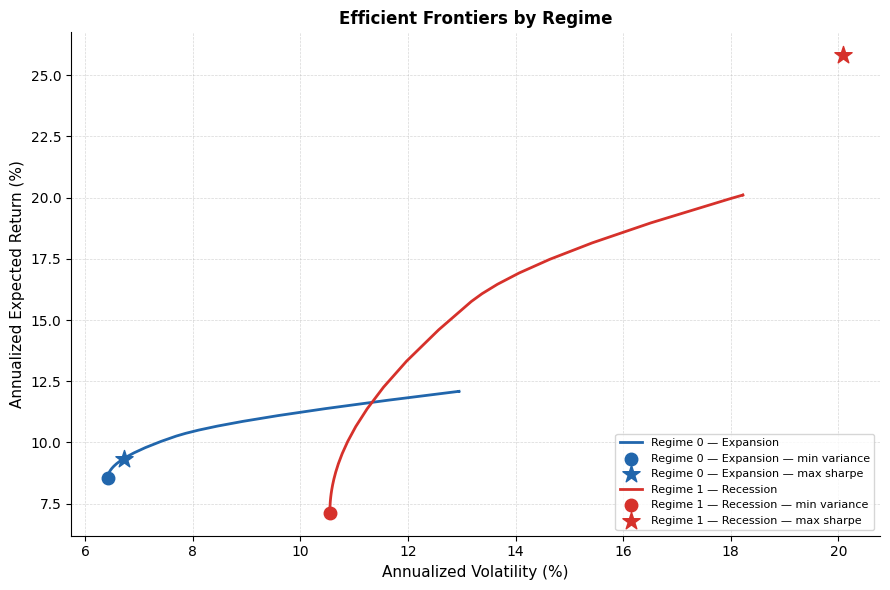

In [25]:
asset_names = market_train.columns[:-1]

print("=" * 55)
print("Regime-Conditional MVO")
print("=" * 55)
results = optimize_regimes(moments, asset_names, rf=0.0, long_only=False)

print("\n" + "=" * 55)
print("Efficient Frontiers")
print("=" * 55)
plot_frontiers(moments, asset_names, results)
plt.show()

### Target weights export

In [26]:
output_path = os.path.join("..", "outputs/tables")
weights_by_regime = {
    k: results[k]['min_variance'].weights
    for k in results
}

rows = []
for date, regime in states_sequence_series.items():
    w = weights_by_regime[regime]
    rows.append({
        'Date':   date,
        'Regime': regime,
        'Equity': w[0],
        'Bonds':  w[1],
        'Gold':   w[2],
    })

df_target_weights = pd.DataFrame(rows).set_index('Date')
df_target_weights.to_csv(os.path.join(output_path, "hmm_target_weights.csv"))
df_target_weights.head()

,Regime,Equity,Bonds,Gold
Date,,,,
1990-02-28,0,0.304427,0.448602,0.246971
1990-03-31,0,0.304427,0.448602,0.246971
1990-04-30,0,0.304427,0.448602,0.246971
1990-05-31,0,0.304427,0.448602,0.246971
1990-06-30,0,0.304427,0.448602,0.246971


### Backtesting


PERFORMANCE METRICS
                   Ann. Return (%) Ann. Volatility (%) Sharpe Ratio Max Drawdown (%) VaR 95% (%) CVaR 95% (%)
HMM Dynamic                 10.59%              10.07%        1.051          -21.95%       3.32%        5.20%
Equal Weight (1/n)          12.21%               9.60%        1.272          -19.61%       3.06%        4.84%
60/40                       10.23%              12.64%        0.809          -25.73%       5.12%        6.83%


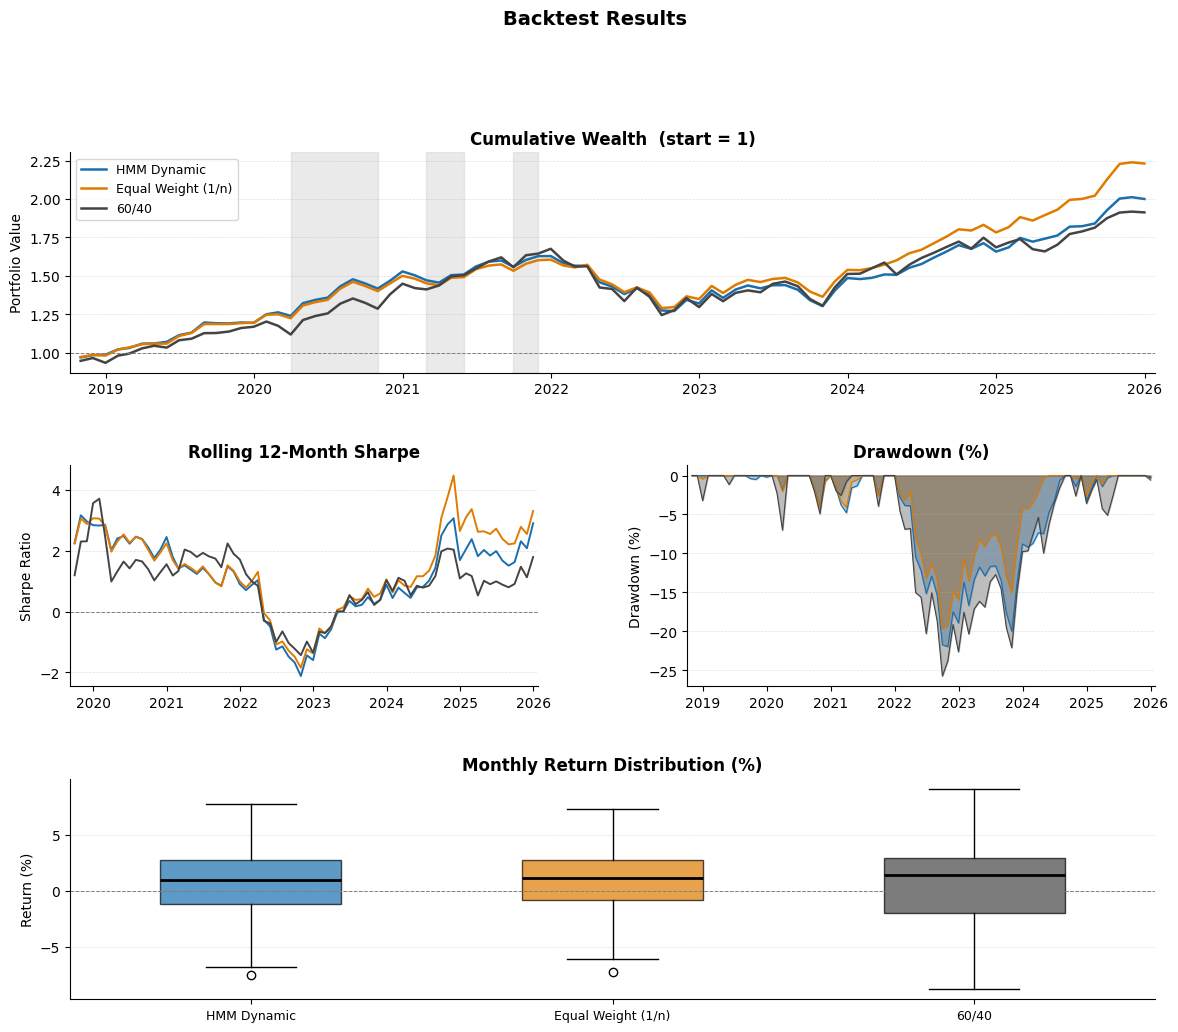

In [27]:
regime_weights = {
    0: results[0]['min_variance'].weights,
    1: results[1]['min_variance'].weights,
}

backtest = run_backtest(
    df_test        = market_test,
    asset_cols     = market_test.columns[:-1].tolist(),
    state_col      = 'HMM State',
    regime_weights = regime_weights,
    equity_col     = 'Equity',
    bond_col       = 'Bonds',
    rf             = 0.0,
    freq           = 12,
    confidence     = 0.95,
    tc_bps         = 0.0,
)

print_metrics_table(backtest['metrics'])
plot_backtest(backtest, state_series=market_test['HMM State'])
plt.show()

### MVO (Max-Sharpe / Tangency) Portfolio

Compute the maximum Sharpe ratio (tangency) portfolio for each regime.

In [28]:
from src.portfolio import MeanVariancePortfolio

mvo_weights_by_regime = {}
print('MVO (Tangency) Weights:')
print('=' * 55)
for k, m in moments.items():
    mvp = MeanVariancePortfolio(
        mu=m['mu'], Sigma=m['sigma'],
        asset_names=list(asset_names),
        rf=0.0, long_only=True, regime=k,
    )
    res = mvp.tangency()
    mvo_weights_by_regime[k] = res.weights
    print(f'  Regime {k}: Equity={res.weights[0]:.3f}  '
          f'Bonds={res.weights[1]:.3f}  Gold={res.weights[2]:.3f}  '
          f'Sharpe(ann)={res.sharpe * (12**0.5):.3f}')

rows_mvo = []
for date, regime in states_sequence_series.items():
    w = mvo_weights_by_regime[regime]
    rows_mvo.append({'Date': date, 'Regime': regime,
                     'Equity': w[0], 'Bonds': w[1], 'Gold': w[2]})

df_mvo_weights = pd.DataFrame(rows_mvo).set_index('Date')
df_mvo_weights.to_csv(os.path.join(output_path, 'hmm_mvo_target_weights.csv'))
print('\nSaved: hmm_mvo_target_weights.csv')
df_mvo_weights.head()

MVO (Tangency) Weights:
  Regime 0: Equity=0.400  Bonds=0.470  Gold=0.130  Sharpe(ann)=1.390
  Regime 1: Equity=0.000  Bonds=0.692  Gold=0.308  Sharpe(ann)=1.205

Saved: hmm_mvo_target_weights.csv


,Regime,Equity,Bonds,Gold
Date,,,,
1990-02-28,0,0.400115,0.470091,0.129794
1990-03-31,0,0.400115,0.470091,0.129794
1990-04-30,0,0.400115,0.470091,0.129794
1990-05-31,0,0.400115,0.470091,0.129794
1990-06-30,0,0.400115,0.470091,0.129794


In [29]:
from src.backtest import backtest_with_transaction_costs
from src.data_loader import load_asset_data
from src.constants import ASSET_COLS

asset_returns_full = load_asset_data('../data/market_clean.csv')[ASSET_COLS].sort_index()

mvo_test_weights = df_mvo_weights.rename(columns={
    'Equity': 'index_fund', 'Bonds': 'treasury_fund', 'Gold': 'gold_fund'
})

SIGNAL_START_HMM = pd.Timestamp('2018-10-31')
mvo_test_weights = mvo_test_weights.loc[mvo_test_weights.index >= SIGNAL_START_HMM].copy()

result_mvo = backtest_with_transaction_costs(
    target_weights=mvo_test_weights,
    asset_returns=asset_returns_full,
    transaction_cost_bps=10,
    apply_signal_lag=True,
    include_initial_trade_cost=False,
)

first_date = result_mvo.index[0]
result_mvo.loc[first_date, 'trade_notional']         = 0.0
result_mvo.loc[first_date, 'one_way_turnover']       = 0.0
result_mvo.loc[first_date, 'transaction_cost']       = 0.0
result_mvo.loc[first_date, 'net_return_after_costs'] = result_mvo.loc[first_date, 'gross_return']

result_mvo.to_csv(os.path.join(output_path, 'hmm_mvo_monthly_returns_with_costs.csv'))
print(f'Test period: {result_mvo.index.min().date()} to {result_mvo.index.max().date()}')

net_ret = result_mvo['net_return_after_costs']
geo_mean = (1 + net_ret).prod() ** (12 / len(net_ret)) - 1
vol = net_ret.std() * np.sqrt(12)
sharpe = (geo_mean - 0.02664) / vol
print(f'\nHMM-MVO (net of costs):')
print(f'  Ann. return (geo): {geo_mean*100:.2f}%')
print(f'  Ann. volatility  : {vol*100:.2f}%')
print(f'  Sharpe ratio     : {sharpe:.3f}')

Test period: 2018-11-30 to 2025-12-31

HMM-MVO (net of costs):
  Ann. return (geo): 6.76%
  Ann. volatility  : 10.57%
  Sharpe ratio     : 0.388


## Regime-Shaded Indicator Plots: VIX, FEDFUNDS, and UNRATE

Line color reflects model-classified state; NBER recession bands provide an independent reference.

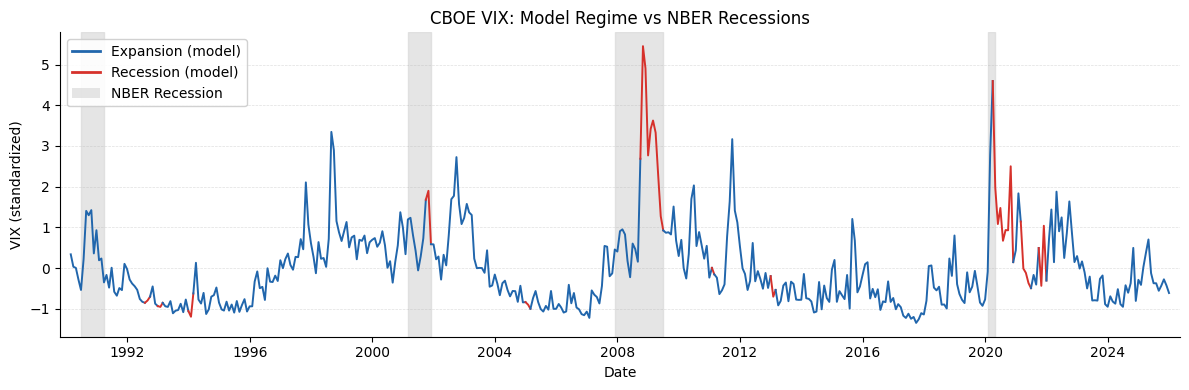

In [30]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='vix', state_col='HMM State',
    recession_state=1,
    title='CBOE VIX: Model Regime vs NBER Recessions',
    ylabel='VIX (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

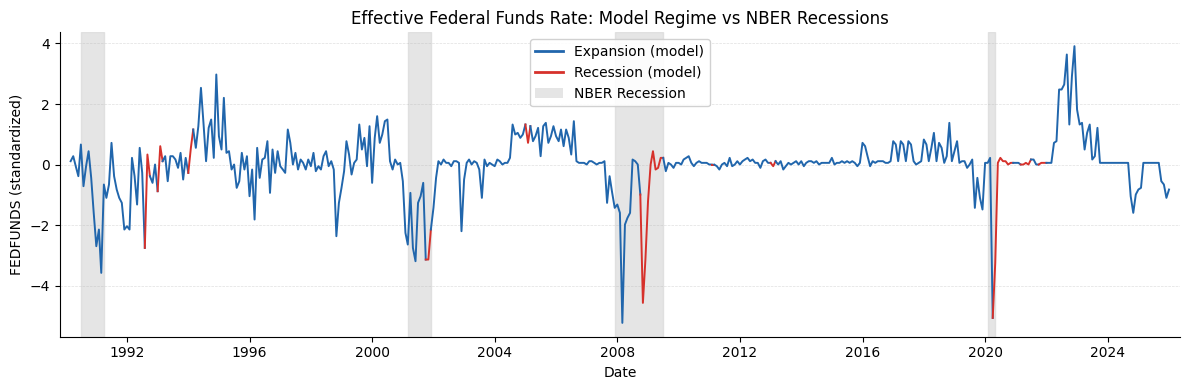

In [31]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='fed_funds_rate', state_col='HMM State',
    recession_state=1,
    title='Effective Federal Funds Rate: Model Regime vs NBER Recessions',
    ylabel='FEDFUNDS (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

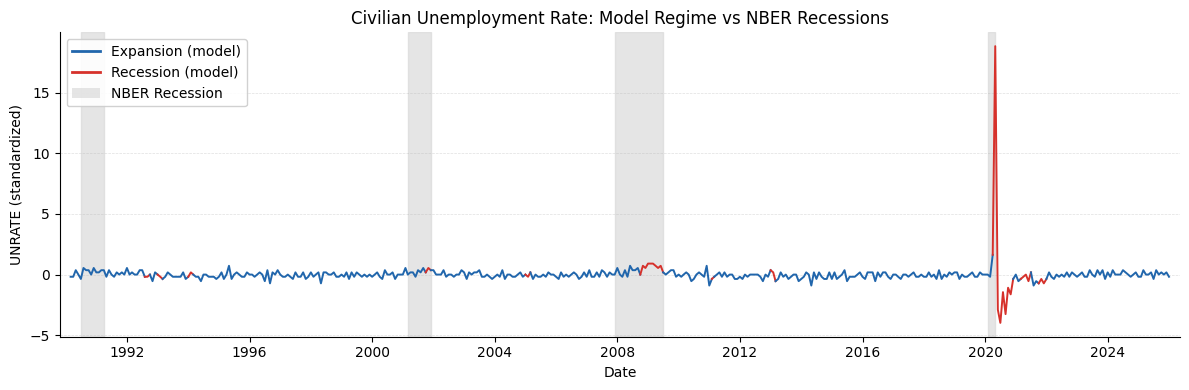

In [32]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='unemployment_rate', state_col='HMM State',
    recession_state=1,
    title='Civilian Unemployment Rate: Model Regime vs NBER Recessions',
    ylabel='UNRATE (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

## Robustness Check: K = 3 Regimes

AIC and BIC are used for model comparison (LR test is non-standard under H0: K=2 per Garcia 1998).

In [33]:
model_k3 = fit_hmm(X_train, K=3, n_iter=200, n_restarts=5, tol=1e-6, random_state=42)

Model is not converging.  Current: -5997.107784655724 is not greater than -5997.107784614895. Delta is -4.0829036151990294e-08
Model is not converging.  Current: -5930.833643555842 is not greater than -5930.833620352752. Delta is -2.3203089767775964e-05


Best log-likelihood (per sample): -5538.6812


In [34]:
T, N = X_train.shape

def hmm_n_params(K, N):
    return (K - 1) + K * (K - 1) + K * N + K * N * (N + 1) // 2

ll_k2 = model.score(X_train)
ll_k3 = model_k3.score(X_train)

np_k2 = hmm_n_params(2, N)
np_k3 = hmm_n_params(3, N)

lr_stat = 2 * (ll_k3 - ll_k2)
delta_df = np_k3 - np_k2

summary_k3 = pd.DataFrame({
    'K': [2, 3],
    'Log-Likelihood': [ll_k2, ll_k3],
    'N Parameters':   [np_k2, np_k3],
    'AIC': [-2*ll_k2 + 2*np_k2, -2*ll_k3 + 2*np_k3],
    'BIC': [-2*ll_k2 + np_k2*np.log(T), -2*ll_k3 + np_k3*np.log(T)],
})
print(f'LR statistic (K=2 vs K=3): {lr_stat:.2f}  (delta_df = {delta_df})')
print('Note: LR p-value non-standard under H0 — use AIC/BIC.')
summary_k3

LR statistic (K=2 vs K=3): 306.48  (delta_df = 109)
Note: LR p-value non-standard under H0 — use AIC/BIC.


,K,Log-Likelihood,N Parameters,AIC,BIC
0,2,-5691.918876,211,11805.837751,12663.786558
1,3,-5538.681167,320,11717.362333,13018.516922


In [35]:
states_k3 = model_k3.predict(X_train)
print('K=3 state counts:', dict(zip(*np.unique(states_k3, return_counts=True))))

means_k3 = pd.DataFrame(
    model_k3.means_,
    columns=macro_df.columns,
    index=[f'State {k}' for k in range(3)]
).T

key_vars = ['vix', 'credit_spread', 'unemployment_rate',
            'industrial_production', 'fed_funds_rate']
means_k3.loc[key_vars]

K=3 state counts: {np.int64(0): np.int64(51), np.int64(1): np.int64(379), np.int64(2): np.int64(1)}


,State 0,State 1,State 2
vix,0.909143,-0.129476,1.978981
credit_spread,0.836329,-0.117774,1.316344
unemployment_rate,-0.190680,-0.023716,18.829716
industrial_production,-0.189612,0.062555,-13.861943
fed_funds_rate,-0.031466,0.012879,-3.245208


In [36]:
summary_k3.to_csv(os.path.join(output_path, 'hmm_k3_model_selection.csv'), index=False)
means_k3.loc[key_vars].to_csv(os.path.join(output_path, 'hmm_k3_regime_means.csv'))
print('Saved K=3 HMM results.')

Saved K=3 HMM results.
